# 06 – Regime Detector + Parameter Tuning

Two improvements on top of raw strategies:
1. **Regime filter** — go to cash when price is below its 200-day MA
2. **Grid search** — find the best fast/slow window sizes per asset

In [1]:
import sys
sys.path.insert(0, '..')

import pandas as pd
import matplotlib.pyplot as plt
from core.data_fetcher import get_data
from core.regime_detector import detect_regime, RegimeFilteredStrategy
from strategies import MACrossStrategy, MomentumStrategy, RSIStrategy
from backtesting import BacktestEngine, ParamTuner

%matplotlib inline
plt.rcParams['figure.figsize'] = (14, 5)

## 1 – Load data
First run downloads and caches to `../data/`. Subsequent runs load from disk instantly.

In [2]:
TICKER = 'AAPL'    # change to 'CRH.L', 'SHEL.L', etc.
df = get_data(TICKER, source='yfinance', period='3y')
print(f'{len(df)} bars  {df.index[0].date()} → {df.index[-1].date()}')
df.tail(3)

752 bars  2023-06-05 → 2026-06-03


,open,high,low,close,volume
date,,,,,
2026-06-01,309.630005,310.940002,305.019989,306.309998,48849900
2026-06-02,307.459991,315.450012,306.690002,315.200012,44416900
2026-06-03,314.174988,316.940002,313.529999,313.529999,10318406


## 2 – Regime detection
Visualise bull/bear/neutral regimes on the price chart.

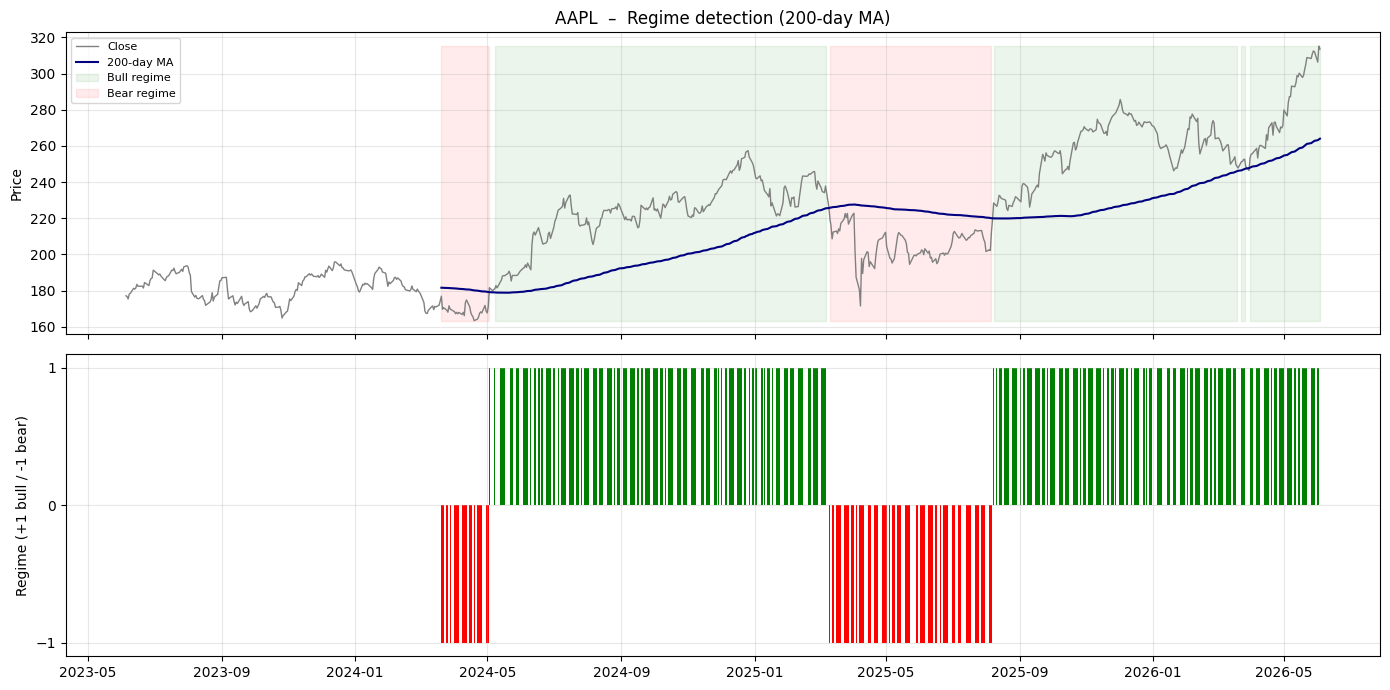

Regime breakdown:
bull       412
neutral    206
bear       134
Name: count, dtype: int64


In [3]:
regime = detect_regime(df, ma_window=200, band_pct=0.01)
ma200  = df['close'].rolling(200).mean()

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(14, 7), sharex=True)

ax1.plot(df.index, df['close'], lw=1, color='grey', label='Close')
ax1.plot(df.index, ma200, lw=1.5, color='navy', label='200-day MA')
ax1.fill_between(df.index, df['close'].min(), df['close'].max(),
                 where=(regime == 1),  alpha=0.08, color='green', label='Bull regime')
ax1.fill_between(df.index, df['close'].min(), df['close'].max(),
                 where=(regime == -1), alpha=0.08, color='red',   label='Bear regime')
ax1.set_ylabel('Price')
ax1.legend(fontsize=8)
ax1.grid(True, alpha=0.3)
ax1.set_title(f'{TICKER}  –  Regime detection (200-day MA)')

regime_pct = regime.value_counts(normalize=True) * 100
ax2.bar(regime.index, regime, color=regime.map({1:'green', 0:'gold', -1:'red'}))
ax2.set_ylabel('Regime (+1 bull / -1 bear)')
ax2.set_yticks([-1, 0, 1])
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()
print('Regime breakdown:')
print(regime.map({1:'bull', 0:'neutral', -1:'bear'}).value_counts())

## 3 – Regime-filtered vs raw strategy

In [4]:
engine = BacktestEngine(initial_capital=10_000)

raw_strat      = MomentumStrategy(lookback=20)
filtered_strat = RegimeFilteredStrategy(MomentumStrategy(lookback=20), ma_window=200)
short_strat    = RegimeFilteredStrategy(MomentumStrategy(lookback=20), ma_window=200, allow_short=True)

r_raw      = engine.run(raw_strat,      df, ticker=TICKER)
r_filtered = engine.run(filtered_strat, df, ticker=TICKER)
r_short    = engine.run(short_strat,    df, ticker=TICKER)

# Side-by-side metrics
comparison = pd.DataFrame({
    'Raw momentum':            r_raw.metrics,
    'Regime-filtered (cash)':  r_filtered.metrics,
    'Regime-filtered (short)': r_short.metrics,
}).T[['ann_return', 'sharpe_ratio', 'max_drawdown', 'win_rate']]

comparison.style.background_gradient(cmap='RdYlGn', subset=['sharpe_ratio', 'ann_return'])

,ann_return,sharpe_ratio,max_drawdown,win_rate
Raw momentum,-0.060300,-0.112400,-0.400900,0.472100
Regime-filtered (cash),0.027400,0.243600,-0.323300,0.281900
Regime-filtered (short),-0.010000,0.077800,-0.370300,0.365700


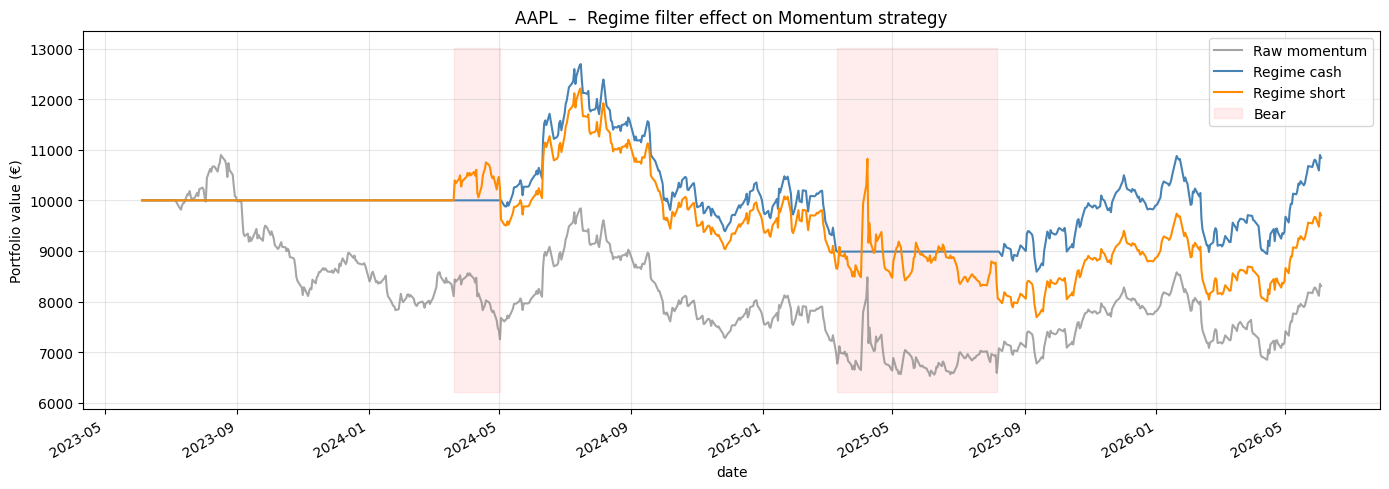

In [5]:
# Equity curves overlay
fig, ax = plt.subplots(figsize=(14, 5))
r_raw.equity_curve.plot(ax=ax, label='Raw momentum', color='grey', alpha=0.7)
r_filtered.equity_curve.plot(ax=ax, label='Regime cash', color='steelblue')
r_short.equity_curve.plot(ax=ax, label='Regime short', color='darkorange')
# shade bear periods
regime = detect_regime(df)
for idx in r_raw.equity_curve.index:
    pass  # background shading done below
ymin, ymax = ax.get_ylim()
ax.fill_between(df.index, ymin, ymax,
                where=(regime == -1), alpha=0.07, color='red', label='Bear')
ax.set_title(f'{TICKER}  –  Regime filter effect on Momentum strategy')
ax.set_ylabel('Portfolio value (€)')
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

## 4 – Parameter tuning: MA Cross
Grid search over fast/slow window sizes.

In [6]:
grid = {
    'fast': [5, 10, 15, 20, 30],
    'slow': [30, 50, 75, 100, 150, 200],
}

tuner_ma = ParamTuner(
    MACrossStrategy, grid, df,
    metric='sharpe_ratio',
    commission=0.001,
)
tuner_ma.run(verbose=True)

Grid search: 30 combinations × full backtest
Best params: {'fast': np.int64(30), 'slow': np.int64(50)}  →  sharpe_ratio=0.6211


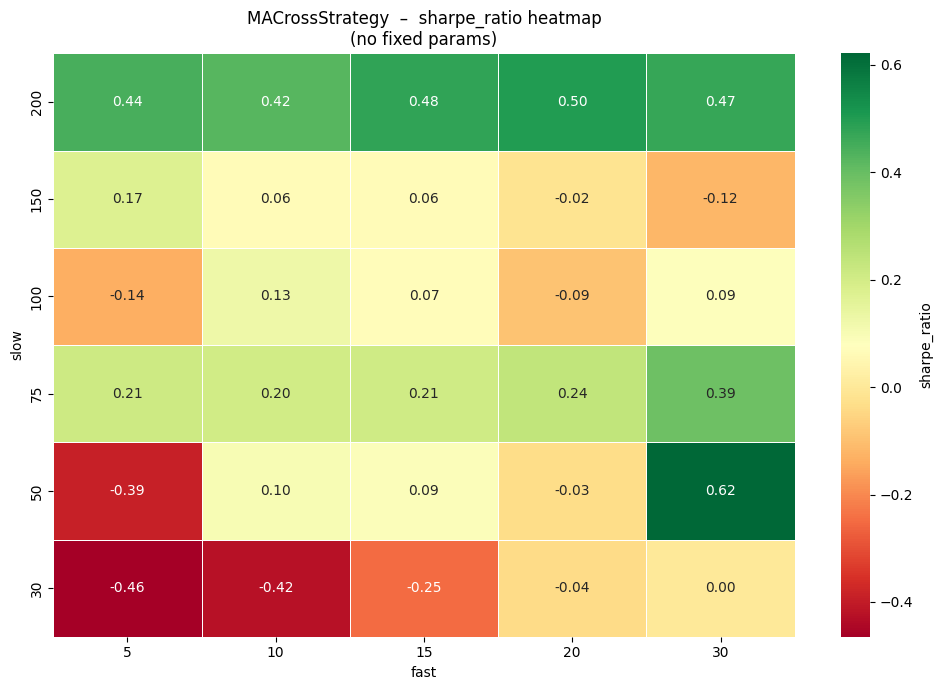

In [7]:
tuner_ma.plot_heatmap('fast', 'slow')

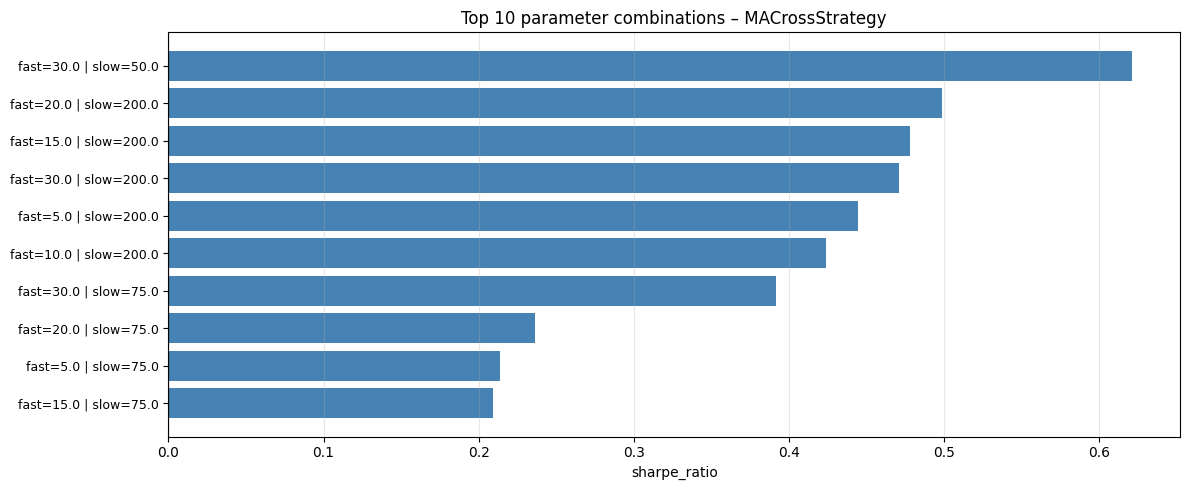


Top 10 results:


,fast,slow,sharpe_ratio,ann_return,max_drawdown
0,30,50,0.6211,0.1336,-0.2493
1,20,200,0.4986,0.0947,-0.3001
2,15,200,0.4784,0.0894,-0.3001
3,30,200,0.4712,0.0875,-0.3143
4,5,200,0.4445,0.0806,-0.3293
5,10,200,0.4241,0.0753,-0.3163
6,30,75,0.3918,0.0688,-0.2567
7,20,75,0.2361,0.0279,-0.2781
8,5,75,0.2138,0.0221,-0.3496
9,15,75,0.2090,0.0209,-0.3592


In [8]:
tuner_ma.plot_top_n(n=10)
print('\nTop 10 results:')
display(tuner_ma.results_table().head(10)[['fast', 'slow', 'sharpe_ratio', 'ann_return', 'max_drawdown']])

## 5 – Parameter tuning: Momentum

Grid search: 28 combinations × full backtest
Best params: {'lookback': np.int64(60), 'threshold': np.float64(0.0)}  →  sharpe_ratio=0.6486


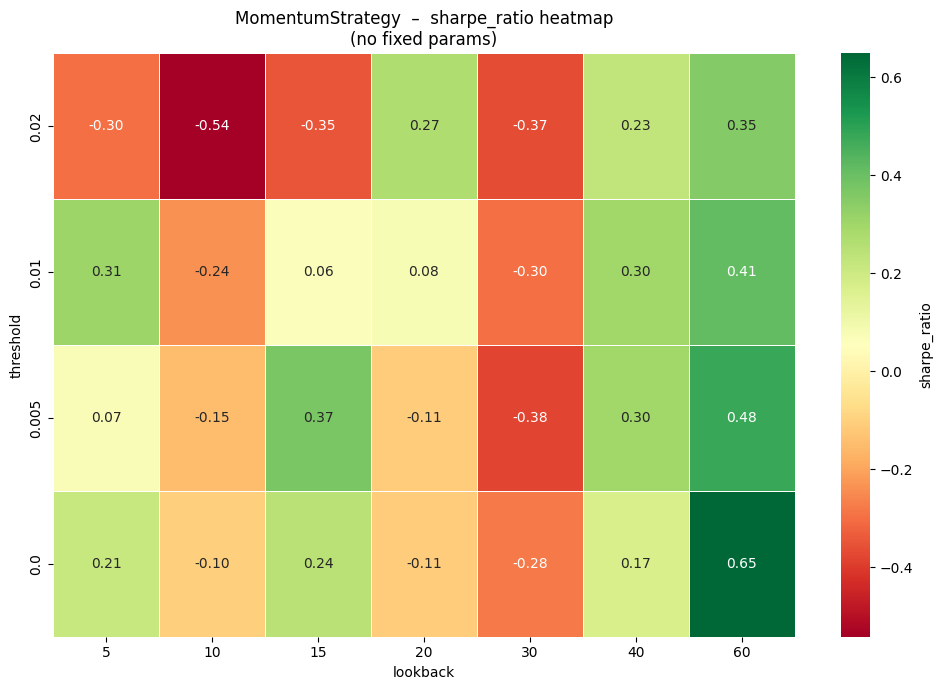

In [9]:
grid_mom = {
    'lookback':  [5, 10, 15, 20, 30, 40, 60],
    'threshold': [0.0, 0.005, 0.01, 0.02],
}

tuner_mom = ParamTuner(MomentumStrategy, grid_mom, df, metric='sharpe_ratio')
tuner_mom.run()
tuner_mom.plot_heatmap('lookback', 'threshold')

## 6 – Walk-forward tuning (avoids overfitting)
Splits the data into 5 folds, tunes on each fold, reports out-of-sample consistency.

In [10]:
tuner_wf = ParamTuner(
    MACrossStrategy, grid, df,
    metric='sharpe_ratio',
    walk_forward_splits=5,
)
tuner_wf.run()
print('\nBest params (walk-forward):', tuner_wf.best_params())
display(tuner_wf.results_table().head(10)[['fast', 'slow', 'sharpe_ratio', 'sharpe_ratio_std']])

Grid search: 30 combinations × WF 5 folds
Best params: {'fast': np.int64(30), 'slow': np.int64(75)}  →  sharpe_ratio=0.4465

Best params (walk-forward): {'fast': np.int64(30), 'slow': np.int64(75)}


,fast,slow,sharpe_ratio,sharpe_ratio_std
0,30,75,0.44646,1.163821
1,30,50,0.32590,0.848637
2,10,75,0.20022,1.273123
3,5,75,0.16492,0.725896
4,20,75,0.16202,1.291192
5,15,75,0.14420,1.615643
6,15,150,0.00000,0.000000
7,15,200,0.00000,0.000000
8,20,200,0.00000,0.000000
9,20,150,0.00000,0.000000


## 7 – Putting it all together: tune + regime filter

Best MA params: {'fast': np.int64(30), 'slow': np.int64(50)}

Optimised + regime-filtered MA Cross:
  total_return        : 0.2968
  ann_return          : 0.091
  ann_volatility      : 0.1698
  sharpe_ratio        : 0.5976
  sortino_ratio       : 0.5875
  calmar_ratio        : 0.3884
  max_drawdown        : -0.2343
  win_rate            : 0.2992
  num_trades          : 414


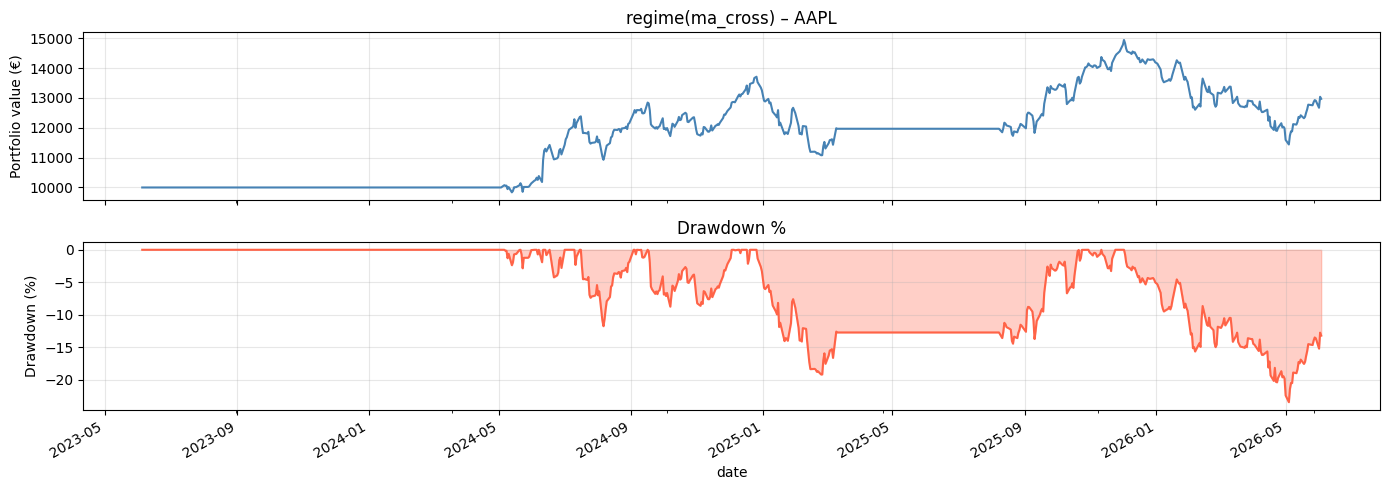

In [11]:
# 1. Find best MA params
best_ma_params = tuner_ma.best_params()
print('Best MA params:', best_ma_params)

# 2. Wrap with regime filter
optimised = RegimeFilteredStrategy(
    MACrossStrategy(**best_ma_params),
    ma_window=200,
    band_pct=0.01,
)

# 3. Backtest
result = BacktestEngine().run(optimised, df, ticker=TICKER)
print(f'\nOptimised + regime-filtered MA Cross:')
for k, v in result.metrics.items():
    print(f'  {k:20s}: {v}')

result.plot()